# Cross-Sectional Short-Term Reversal — Backtest & Graphs


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import reversal_backtest as rb

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Get data

Set `USE_SYNTHETIC = False` to pull real prices via `yfinance` (needs internet).
Leave it `True` to instantly test the notebook with simulated data that has a
known, engineered reversal effect baked in — useful for confirming the plots
and pipeline work before waiting on a real download or debugging a small
universe.

In [38]:
USE_SYNTHETIC = False  # flip to False once you have internet access to Yahoo Finance

if USE_SYNTHETIC:
    np.random.seed(42)
    n_days, n_names = 800, 30
    dates = pd.bdate_range("2021-01-01", periods=n_days)
    tickers = [f"T{i:02d}" for i in range(n_names)]

    market_ret = np.random.normal(0.0003, 0.01, n_days)
    idio = np.zeros((n_days, n_names))
    phi = -0.08  # negative autocorrelation -> engineered reversal effect
    for t in range(1, n_days):
        idio[t] = phi * idio[t - 1] + np.random.normal(0, 0.015, n_names)

    returns_df = pd.DataFrame(idio + market_ret[:, None], index=dates, columns=tickers)
    close = 100 * (1 + returns_df).cumprod()
    volume = pd.DataFrame(np.random.uniform(1e6, 5e6, size=(n_days, n_names)),
                           index=dates, columns=tickers)
else:
    tickers = [
        "AAPL", "MSFT", "AMZN", "GOOGL", "META", "NVDA", "TSLA", "JPM", "V", "UNH",
        "HD", "PG", "MA", "DIS", "BAC", "XOM", "PFE", "KO", "PEP", "CSCO",
        "INTC", "T", "VZ", "ABT", "CRM", "NKE", "MRK", "WMT", "MCD", "ADBE",
    ]
    close, volume = rb.download_universe(tickers, rb.CONFIG["start_date"], rb.CONFIG["end_date"])

print(f"Universe: {close.shape[1]} names, {close.shape[0]} trading days")
close.tail()


Universe: 30 names, 2516 trading days


,AAPL,MSFT,AMZN,GOOGL,META,NVDA,TSLA,JPM,V,UNH,...,INTC,T,VZ,ABT,CRM,NKE,MRK,WMT,MCD,ADBE
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-24,256.560822,434.179352,229.050003,195.090988,604.760864,140.010895,462.279999,235.018585,317.076050,487.342194,...,20.400000,21.486578,36.058937,111.359657,340.463593,74.532791,94.462715,91.438751,285.693146,447.940002
2024-12-26,257.375549,432.973663,227.050003,194.583664,600.382385,139.721329,454.130005,235.823624,317.333160,492.205017,...,20.440001,21.495939,36.203903,111.854538,337.784760,74.678383,94.861671,91.547279,286.480286,450.160004
2024-12-27,253.967377,425.482544,223.750000,191.758377,596.859802,136.805649,431.660004,233.912903,315.108276,491.087982,...,20.299999,21.402317,36.167660,111.582840,334.552490,74.173660,94.700180,90.432411,285.333588,446.480011
2024-12-30,250.598907,419.849335,221.300003,190.246307,588.331970,137.284958,417.410004,232.118546,311.795624,488.979156,...,19.820000,21.168259,35.877735,109.457733,331.873657,72.455696,93.436890,89.357018,281.427032,445.799988
2024-12-31,248.830215,416.558441,219.389999,188.316391,582.630249,134.089737,403.839996,232.496841,312.517487,487.111084,...,20.049999,21.318058,36.231083,109.758553,330.479889,73.445717,94.491219,89.139961,281.708832,444.679993


## 2. Run the backtest

In [39]:
results, weights, signal_z = rb.run_backtest(close, volume, rb.CONFIG)

market_ret = close.pct_change().mean(axis=1)
summary = rb.performance_summary(results)
factor_stats = rb.factor_decomposition(results, market_ret)

print("=== Performance Summary ===")
print(summary.round(4))
print("\n=== Factor Decomposition ===")
for k, v in factor_stats.items():
    print(f"{k}: {v:.5f}")


=== Performance Summary ===
Gross Ann. Return       -0.0205
Net Ann. Return         -0.5640
Gross Sharpe            -0.0931
Net Sharpe              -2.5620
Avg Daily Turnover       2.8618
Avg Daily Cost (bps)    21.5663
Max Drawdown (net)      -0.9972
Max Drawdown (gross)    -0.6125
dtype: float64

=== Factor Decomposition ===
alpha_daily: -0.00232
alpha_annualized: -0.58410
beta_mkt: 0.10505


## 3. Cumulative return: gross vs. net

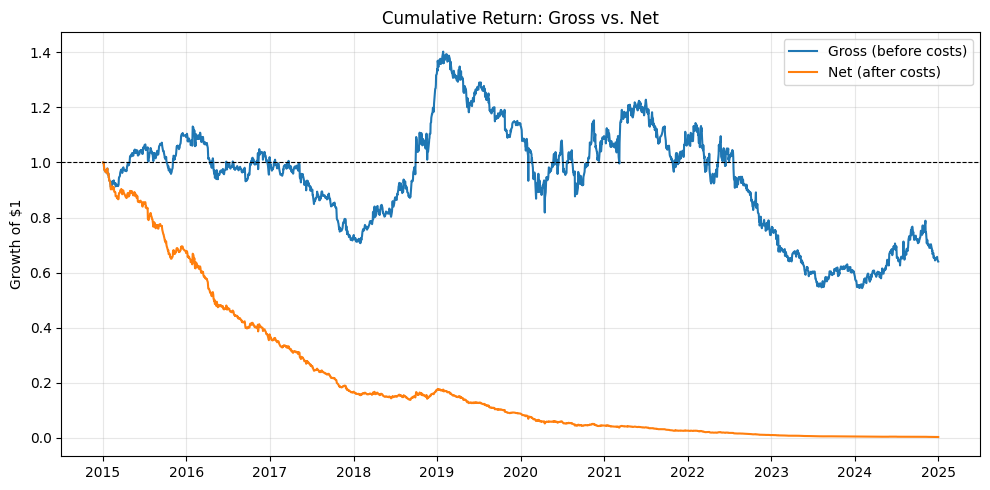

In [40]:
cum_gross = (1 + results["gross_ret"]).cumprod()
cum_net = (1 + results["net_ret"]).cumprod()

fig, ax = plt.subplots()
ax.plot(cum_gross.index, cum_gross.values, label="Gross (before costs)", linewidth=1.5)
ax.plot(cum_net.index, cum_net.values, label="Net (after costs)", linewidth=1.5)
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Return: Gross vs. Net")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Drawdown curve (net)

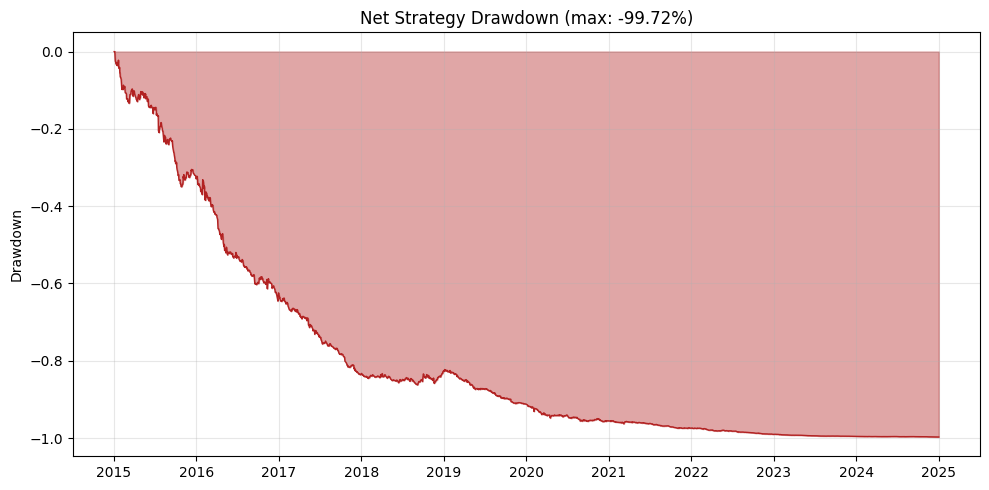

In [41]:
running_max = cum_net.cummax()
drawdown = cum_net / running_max - 1

fig, ax = plt.subplots()
ax.fill_between(drawdown.index, drawdown.values, 0, color="firebrick", alpha=0.4)
ax.plot(drawdown.index, drawdown.values, color="firebrick", linewidth=1)
ax.set_title(f"Net Strategy Drawdown (max: {drawdown.min():.2%})")
ax.set_ylabel("Drawdown")
plt.tight_layout()
plt.show()


## 5. Rolling turnover and cost drag

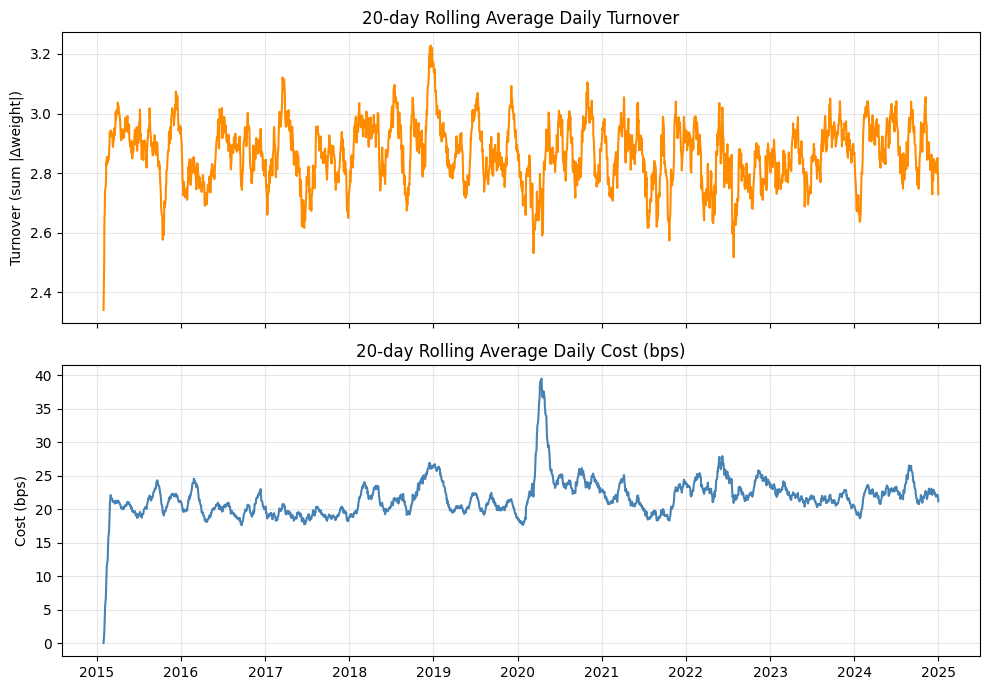

In [42]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 7))

axes[0].plot(results.index, results["turnover"].rolling(20).mean(), color="darkorange")
axes[0].set_title("20-day Rolling Average Daily Turnover")
axes[0].set_ylabel("Turnover (sum |Δweight|)")

axes[1].plot(results.index, (results["cost"] * 1e4).rolling(20).mean(), color="steelblue")
axes[1].set_title("20-day Rolling Average Daily Cost (bps)")
axes[1].set_ylabel("Cost (bps)")

plt.tight_layout()
plt.show()


## 6. Cross-sectional signal distribution

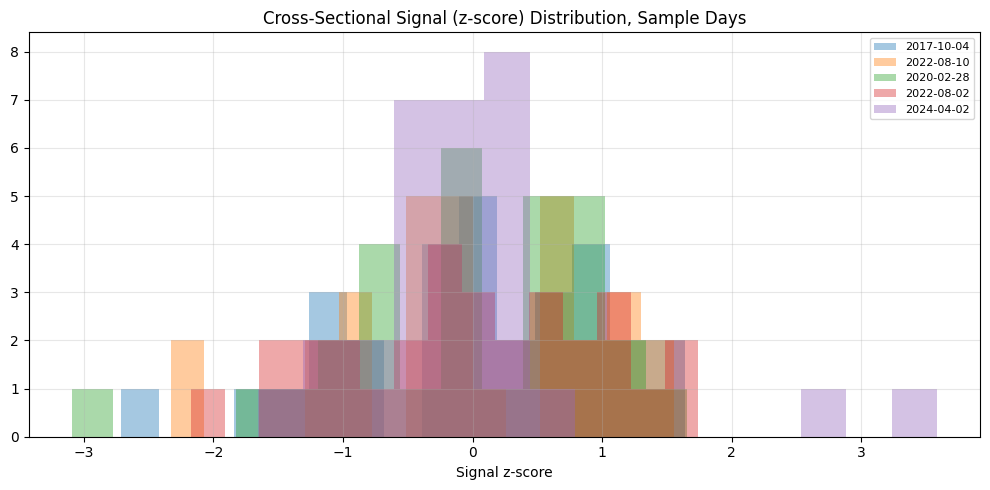

In [43]:
fig, ax = plt.subplots()
sample_days = signal_z.dropna(how="all").sample(min(5, signal_z.shape[0]), random_state=1)
for dt, row in sample_days.iterrows():
    ax.hist(row.dropna(), bins=15, alpha=0.4, label=str(dt.date()))
ax.set_title("Cross-Sectional Signal (z-score) Distribution, Sample Days")
ax.set_xlabel("Signal z-score")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 7. Factor exposure check: strategy return vs. market return

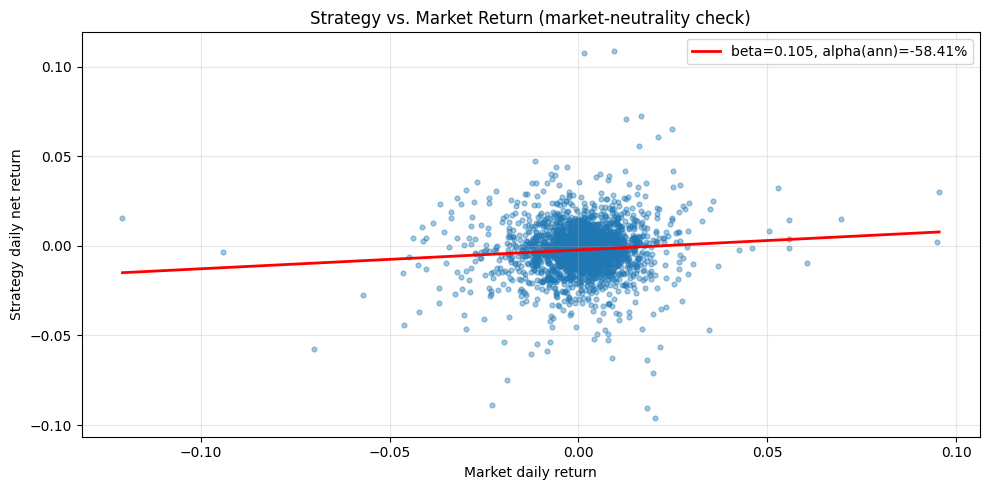

In [44]:
df = pd.concat([results["net_ret"], market_ret], axis=1).dropna()
df.columns = ["strategy", "market"]

fig, ax = plt.subplots()
ax.scatter(df["market"], df["strategy"], alpha=0.4, s=12)
x = np.linspace(df["market"].min(), df["market"].max(), 50)
ax.plot(x, factor_stats["alpha_daily"] + factor_stats["beta_mkt"] * x,
        color="red", linewidth=2,
        label=f"beta={factor_stats['beta_mkt']:.3f}, alpha(ann)={factor_stats['alpha_annualized']:.2%}")
ax.set_xlabel("Market daily return")
ax.set_ylabel("Strategy daily net return")
ax.set_title("Strategy vs. Market Return (market-neutrality check)")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Signal decay across lookback horizons

Re-runs the backtest at several `lookback` values to see whether the effect
is strongest at 1 day and decays, or holds up further out.

               Gross Sharpe  Net Sharpe  Avg Daily Turnover
lookback_days                                              
1                    -0.093      -2.562               2.862
2                     0.159      -1.560               2.014
3                     0.102      -1.291               1.636
5                    -0.126      -1.191               1.252
10                   -0.149      -0.892               0.869


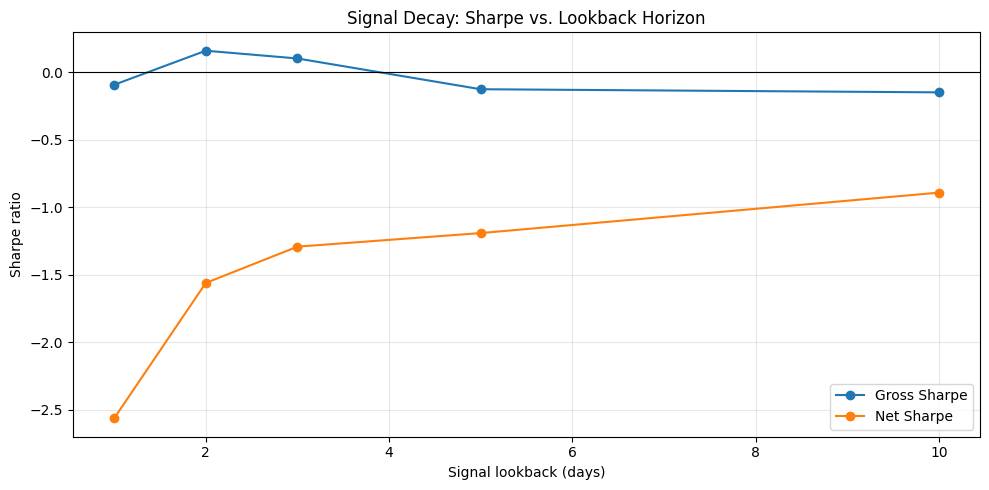

In [45]:
lookbacks = [1, 2, 3, 5, 10]
decay_results = {}

for lb in lookbacks:
    cfg = dict(rb.CONFIG)
    cfg["lookback"] = lb
    res, _, _ = rb.run_backtest(close, volume, cfg)
    decay_results[lb] = rb.performance_summary(res)

decay_df = pd.DataFrame(decay_results).T
decay_df.index.name = "lookback_days"
print(decay_df[["Gross Sharpe", "Net Sharpe", "Avg Daily Turnover"]].round(3))

fig, ax = plt.subplots()
ax.plot(decay_df.index, decay_df["Gross Sharpe"], marker="o", label="Gross Sharpe")
ax.plot(decay_df.index, decay_df["Net Sharpe"], marker="o", label="Net Sharpe")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Signal lookback (days)")
ax.set_ylabel("Sharpe ratio")
ax.set_title("Signal Decay: Sharpe vs. Lookback Horizon")
ax.legend()
plt.tight_layout()
plt.show()
